In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pyreadr import read_r
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
import json
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

t_threshold = 255
ts_df = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")
ts_df = ts_df.loc[ts_df["t"] <= t_threshold]
all_xyz_map = {}
cell_names = ts_df["name"].unique()
valid_cell_names = []
for name in cell_names:
    time_points = ts_df.loc[ts_df['name'] == name]["t"].values
    if len(time_points) == 1 and time_points[0] == t_threshold:
        continue
    all_xyz_map[name] = ts_df.loc[ts_df['name'] == name].values[-1][1:4]*0.1625
    valid_cell_names.append(name)

def map_names(did):
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

embryonic_terminal_cells = pd.read_csv('data/embryonic_terminals.txt', sep='\t', header=None)[0].tolist()
tissue_specific_tfs = pd.read_csv('data/protein/aggregated_all/tissue_specific_tf.tsv', sep='\t', header=None, index_col=0).index.tolist()
nn_selected_tfs = pd.read_csv('data/protein/aggregated_all/nn_selected_proteins_rev.tsv', sep='\t', header=None, index_col=0).index.tolist()


In [2]:
gene_data_df = pd.read_csv('data/gene_data.txt', sep='\t', index_col=0)
gene_data_df.index = gene_data_df.index.str.upper()
gene_data_df.head()

,jsd_median_term,jsd_lower_term,jsd_upper_term,pcor_median_term,pcor_lower_term,pcor_upper_term,scor_median_term,scor_lower_term,scor_upper_term,cos_median_term,...,operon,maternal,RecombRegion,RNAi_or_Allele,embryonic_lethal_direct,embryonic_lethal_direct_inferred,larval_lethal_direct,larval_lethal_direct_inferred,lethal_direct,lethal_direct_inferred
gene,,,,,,,,,,,,,,,,,,,,,
2L52.1,0.450554,0.428416,0.469560,0.289454,0.213473,0.364712,0.352485,0.296098,0.413772,0.365775,...,N.A.,False,II_LeftTip,False,False,False,False,False,False,False
RGA-9,0.350676,0.336391,0.365963,0.603602,0.541112,0.655173,0.627157,0.584258,0.665822,0.235889,...,N.A.,False,II_RightTip,False,False,False,False,False,False,False
NAS-6,0.551291,0.524371,0.576493,0.403508,0.347128,0.455199,0.286374,0.216116,0.356301,0.184228,...,N.A.,False,IV_RightTip,True,False,False,False,False,True,True
RABR-2,0.662402,0.603275,0.711242,0.374094,0.301252,0.449785,0.252592,0.176470,0.325485,0.384001,...,N.A.,False,IV_RightTip,True,False,False,False,False,False,False
SRI-20,0.922031,0.831150,0.980238,0.069098,-0.056399,0.206172,0.144529,0.053946,0.229579,0.886603,...,N.A.,False,V_Center,False,False,False,False,False,False,False


In [3]:
candidate_tfs = set(tissue_specific_tfs) & set(nn_selected_tfs)
candidate_tfs = nn_selected_tfs
print(f"Number of candidate tissue-specific TFs: {len(candidate_tfs)}")

Number of candidate tissue-specific TFs: 15


In [4]:
# get the gene_data_df for all tissue specific TFs that are in the gene_data_df
tissue_specific_tfs_in_gene_data = [tf for tf in candidate_tfs if tf in gene_data_df.index]
tissue_specific_tf_data_df = gene_data_df.loc[tissue_specific_tfs_in_gene_data]
tissue_specific_tf_data_df['cel_tau_median_joint'].sort_values(ascending=False).head(15)


gene
CEH-51    0.882384
HAM-2     0.750088
CEH-45    0.733600
NHR-25    0.706627
EGRH-1    0.646098
PHA-4     0.620859
CEH-27    0.609094
CES-2     0.533962
ALY-2     0.518769
HLH-2     0.459331
SPR-4     0.306175
NFYC-1    0.302150
ALY-1     0.284091
MEP-1     0.230146
Name: cel_tau_median_joint, dtype: float64

In [5]:
include_embryonic_terminals = False


In [ ]:
lineage_exp = pd.read_csv("./data/protein/aggregated_all/embeddings_32d.csv", index_col=0).T
protein_exp = pd.read_csv("./data/protein/aggregated_all/s3_zscore.csv", index_col=0)
binary_protein_exp = pd.read_csv('data/protein/aggregated_all/lineage_binary_expression.csv',  index_col=0)
protein_exp = protein_exp.fillna(0)
protein_exp = protein_exp.loc[protein_exp.sum(axis=1) != 0, :]
lineage_exp = lineage_exp.fillna(0)


FileNotFoundError: [Errno 2] No such file or directory: './data/protein/aggregated_all/embeddings_32d_rev.csv'

In [7]:
protein_pca_exp = pd.read_csv("./data/protein/aggregated_all/s3_pca_10d.csv", index_col=0).T
protein_pca_exp = protein_pca_exp.fillna(0)

In [8]:
protein_tau_values = []
for index_name, row in protein_exp.iterrows():
    protein_name = index_name.split("_")[0]
    if protein_name in tissue_specific_tf_data_df.index:
        tau = (1 - row / row.max()).sum()/(len(row) - 1)
        protein_tau_values.append(tau)


In [9]:
tf_names = set()
for name in protein_exp.index:
    tf_name = name.split('_')[0]
    if '.' in tf_name:
        tf_names.add(tf_name)
    else:
        tf_names.add(tf_name.lower())


In [10]:
selected_rows = []
for protein_name in protein_exp.index:
    tf_name = protein_name.split("_")[0]
    if tf_name in candidate_tfs:
        selected_rows.append(protein_name)
protein_exp = protein_exp.loc[selected_rows, :]
binary_protein_exp = binary_protein_exp.loc[selected_rows, :]

In [11]:
alt_exp = read_r("./data/viscello/lin_sc_expr_190602.rds")[None]
alt_tf_exp = alt_exp.loc[alt_exp.index.isin(tf_names)]

# randomly pick 20 genes as random baseline
random_genes = np.random.choice(alt_exp.index, size=20, replace=False)
random_exp = alt_exp.loc[random_genes]


In [12]:
valid_cell_names = set(valid_cell_names).intersection(set(lineage_exp.columns)).intersection(set(alt_exp.columns))
valid_cell_names = set(valid_cell_names).intersection(set(lineage_exp.columns))

# pca = PCA(n_components=20)
# alt_exp_pca = pca.fit_transform(alt_exp.T)
# alt_exp_pca_df = pd.DataFrame(alt_exp_pca, index=alt_exp.columns,
#                                columns=[f'PC{i+1}' for i in range(20)]).T


In [13]:
# calculate the Jensen Shannon divergence matrix using the binary expression data
def js_divergence(p, q):
    p = np.array(p, dtype=float)
    q = np.array(q, dtype=float)
    sum_p, sum_q = p.sum(), q.sum()
    if sum_p == 0 or sum_q == 0:
        return np.nan
    p /= sum_p
    q /= sum_q
    m = 0.5 * (p + q)
    # Use safe inner where so log is never evaluated at 0/0
    kl_pm = np.sum(np.where(p > 0, p * np.log(np.where(p > 0, p / m, 1.0)), 0.0))
    kl_qm = np.sum(np.where(q > 0, q * np.log(np.where(q > 0, q / m, 1.0)), 0.0))
    return 0.5 * (kl_pm + kl_qm)
def compute_js_distance_matrix(exp_matrix):
    num_cells = exp_matrix.shape[1]
    js_distance_matrix = np.zeros((num_cells, num_cells))
    for i in tqdm(range(num_cells)):
        for j in range(i + 1, num_cells):
            js_distance_matrix[i, j] = js_divergence(exp_matrix[:, i], exp_matrix[:, j])
            js_distance_matrix[j, i] = js_distance_matrix[i, j]
    return js_distance_matrix
js_distance_matrix = compute_js_distance_matrix(binary_protein_exp.values)

  0%|          | 0/1308 [00:00<?, ?it/s]/tmp/ipykernel_591254/1467139771.py:12: RuntimeWarning: invalid value encountered in divide
  kl_pm = np.sum(np.where(p > 0, p * np.log(np.where(p > 0, p / m, 1.0)), 0.0))
/tmp/ipykernel_591254/1467139771.py:13: RuntimeWarning: invalid value encountered in divide
  kl_qm = np.sum(np.where(q > 0, q * np.log(np.where(q > 0, q / m, 1.0)), 0.0))
100%|██████████| 1308/1308 [00:19<00:00, 68.44it/s] 


In [14]:
# fille nan with 0 in js_distance_matrix
js_distance_matrix = np.nan_to_num(js_distance_matrix, nan=0.0)

In [15]:
js_distance_matrix.shape

(1308, 1308)

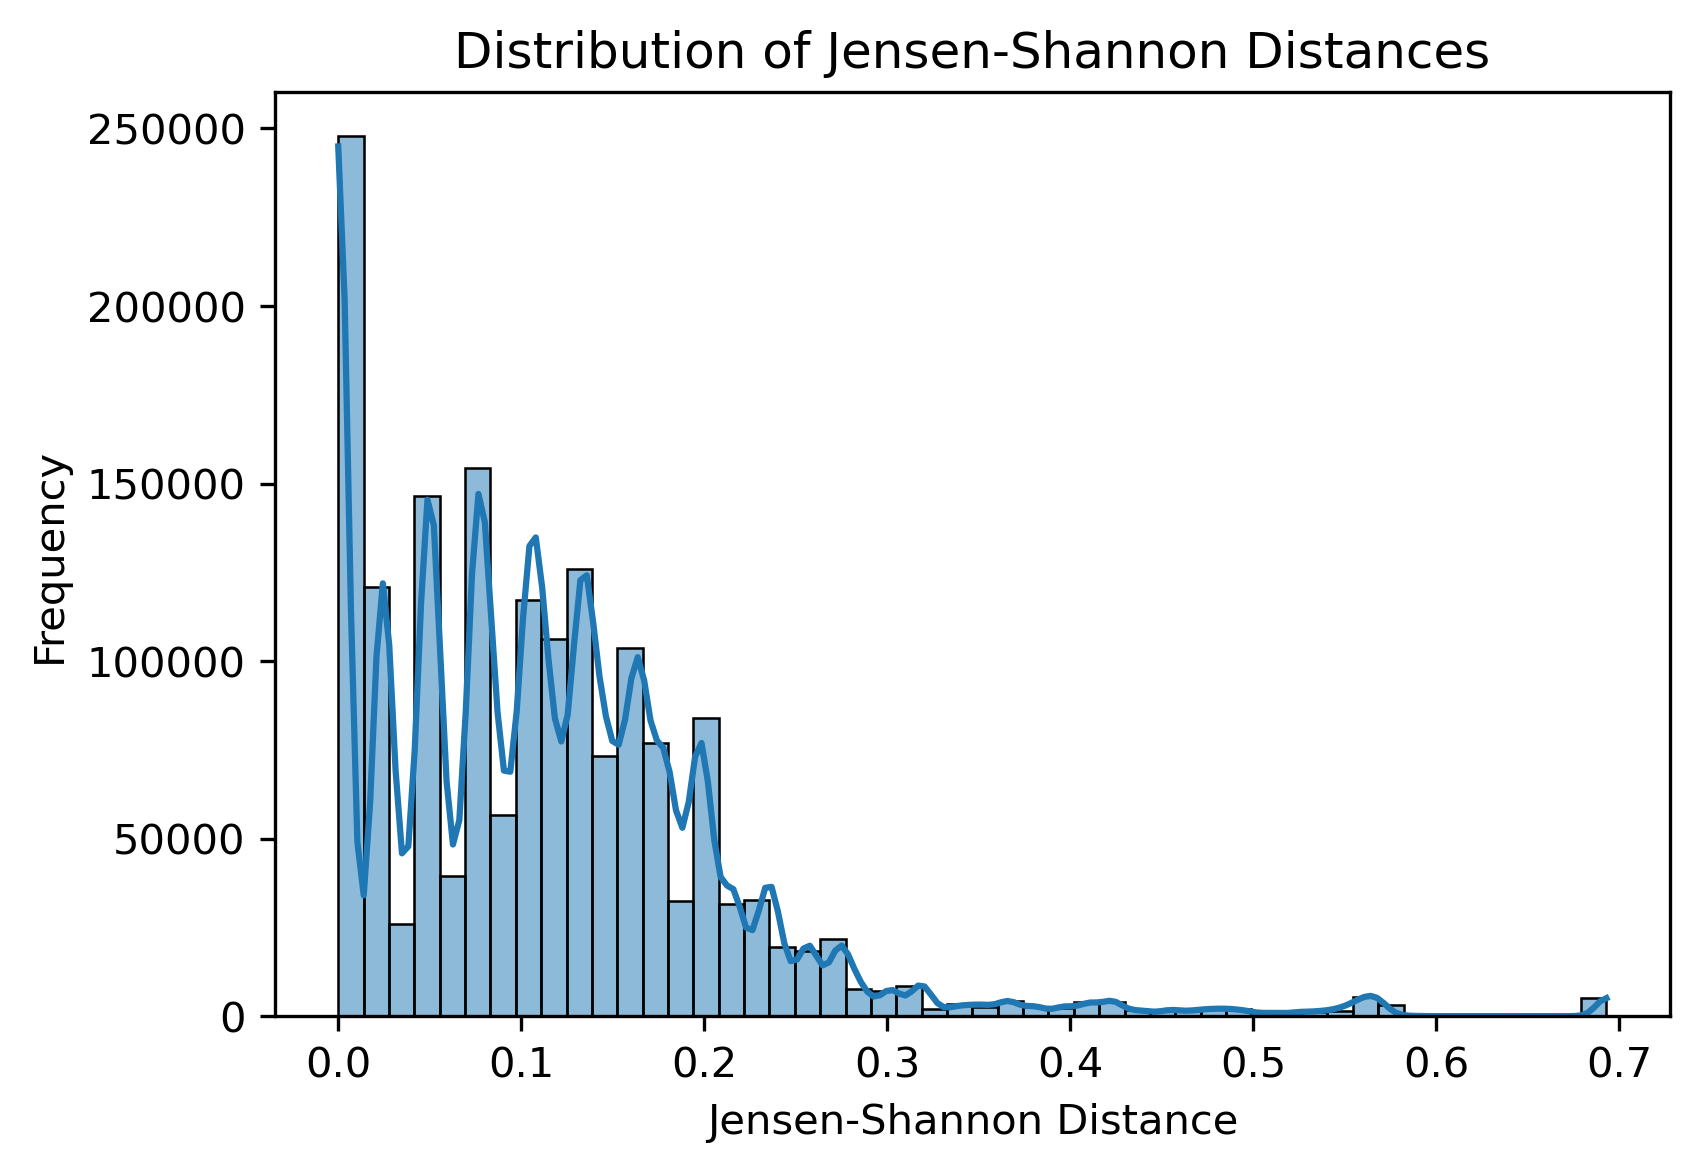

In [16]:
# plot the distribution of js_distance_matrix
plt.figure(figsize=(6, 4))
sns.histplot(js_distance_matrix.flatten(), bins=50, kde=True)
plt.title('Distribution of Jensen-Shannon Distances')
plt.xlabel('Jensen-Shannon Distance')
plt.ylabel('Frequency')
plt.show()

In [17]:
js_distance_matrix_df = pd.DataFrame(js_distance_matrix, index=binary_protein_exp.columns, columns=binary_protein_exp.columns)

In [18]:
def jsd_calc(input_df):
    zscored = input_df.T
    zscored = (zscored - zscored.mean(axis=0)) / (zscored.std(axis=0) + 1e-8)
    shifted = zscored - zscored.min(axis=1).values.reshape(-1, 1)
    pseudocount = 0.01 * np.nanmedian(shifted.values[shifted.values > 0])
    distributions = shifted + pseudocount
    distributions = distributions / distributions.sum(axis=1).values.reshape(-1, 1)
    jsd_matrix = squareform(pdist(distributions, metric='jensenshannon'))
    return jsd_matrix


In [19]:
alt_jsd_matrix = jsd_calc(alt_tf_exp)
alt_jsd_matrix_df = pd.DataFrame(alt_jsd_matrix, index=alt_exp.columns, columns=alt_exp.columns)


In [20]:
cell_type_df = pd.read_csv("data/2023-06-29_entropy_cell_key_V2.csv")
lineage_type_dict = defaultdict(str)
for lineage in lineage_exp.columns:
    cur_cell_type_df = cell_type_df[cell_type_df['wormweb.lineage'] == lineage]
    if cur_cell_type_df.empty:
        continue
    cur_lineage_types = cur_cell_type_df["wormweb.type"]
    cur_lineage_types = cur_lineage_types[~cur_lineage_types.isna()].unique()
    if len(cur_lineage_types) == 0:
        continue
    lineage_type_dict[lineage] = cur_lineage_types[0]


In [21]:
with open('./data/cell_lineage.json', 'r', encoding='utf-8') as f:
    lineage_data = json.load(f)


In [22]:
terminal_nodes = []
terminal_parents = []
terminal_parents_dict = defaultdict(list)
node_ancestry = defaultdict(list)
terminal_name_to_idx = {}

def dfs(node, parent, ancestors=[]):
    children = node.get("children", [])
    lookup_name = map_names(node["did"])
    node_ancestry[lookup_name] = ancestors
    if len(children) == 0 or (include_embryonic_terminals and lookup_name in embryonic_terminal_cells):
        p_lookup_name = map_names(parent['did'])
        if lookup_name in valid_cell_names and p_lookup_name in valid_cell_names:
            terminal_nodes.append(lookup_name)
            terminal_parents.append(p_lookup_name)
            terminal_parents_dict[p_lookup_name].append(lookup_name)
            terminal_name_to_idx[lookup_name] = len(terminal_nodes) - 1
    else:
        for child in children:
            dfs(child, node, ancestors + [lookup_name])

dfs(lineage_data, None)


In [23]:
def lineage_distance(cell1, cell2):
    ancestors1 = node_ancestry[cell1]
    ancestors2 = node_ancestry[cell2]
    common_ancestors = set(ancestors1).intersection(set(ancestors2))
    if not common_ancestors:
        return len(ancestors1) + len(ancestors2)
    last_common_ancestor = max(common_ancestors, key=lambda x: ancestors1.index(x))
    distance = (len(ancestors1) - ancestors1.index(last_common_ancestor) - 1) + (len(ancestors2) - ancestors2.index(last_common_ancestor) - 1)
    return distance

In [24]:
alt_tf_exp_dict = {}
for colname in alt_tf_exp.columns:
    alt_tf_exp_dict[colname] = alt_tf_exp[colname].values

In [25]:
lineage_distances = []
exp_distances = []
for i in tqdm(range(len(binary_protein_exp.columns))):
    for j in range(i + 1, len(binary_protein_exp.columns)):
        cell1 = binary_protein_exp.columns[i]
        cell2 = binary_protein_exp.columns[j]
        dist = lineage_distance(cell1, cell2)
        if cell1 not in lineage_exp or cell2 not in lineage_exp:
            continue
        exp_distance = np.linalg.norm(lineage_exp[cell1] - lineage_exp[cell2])
        exp_distances.append(exp_distance)
        lineage_distances.append(dist)
        # print(f"Lineage distance between {cell1} and {cell2}: {dist}")

100%|██████████| 1308/1308 [00:46<00:00, 27.93it/s] 


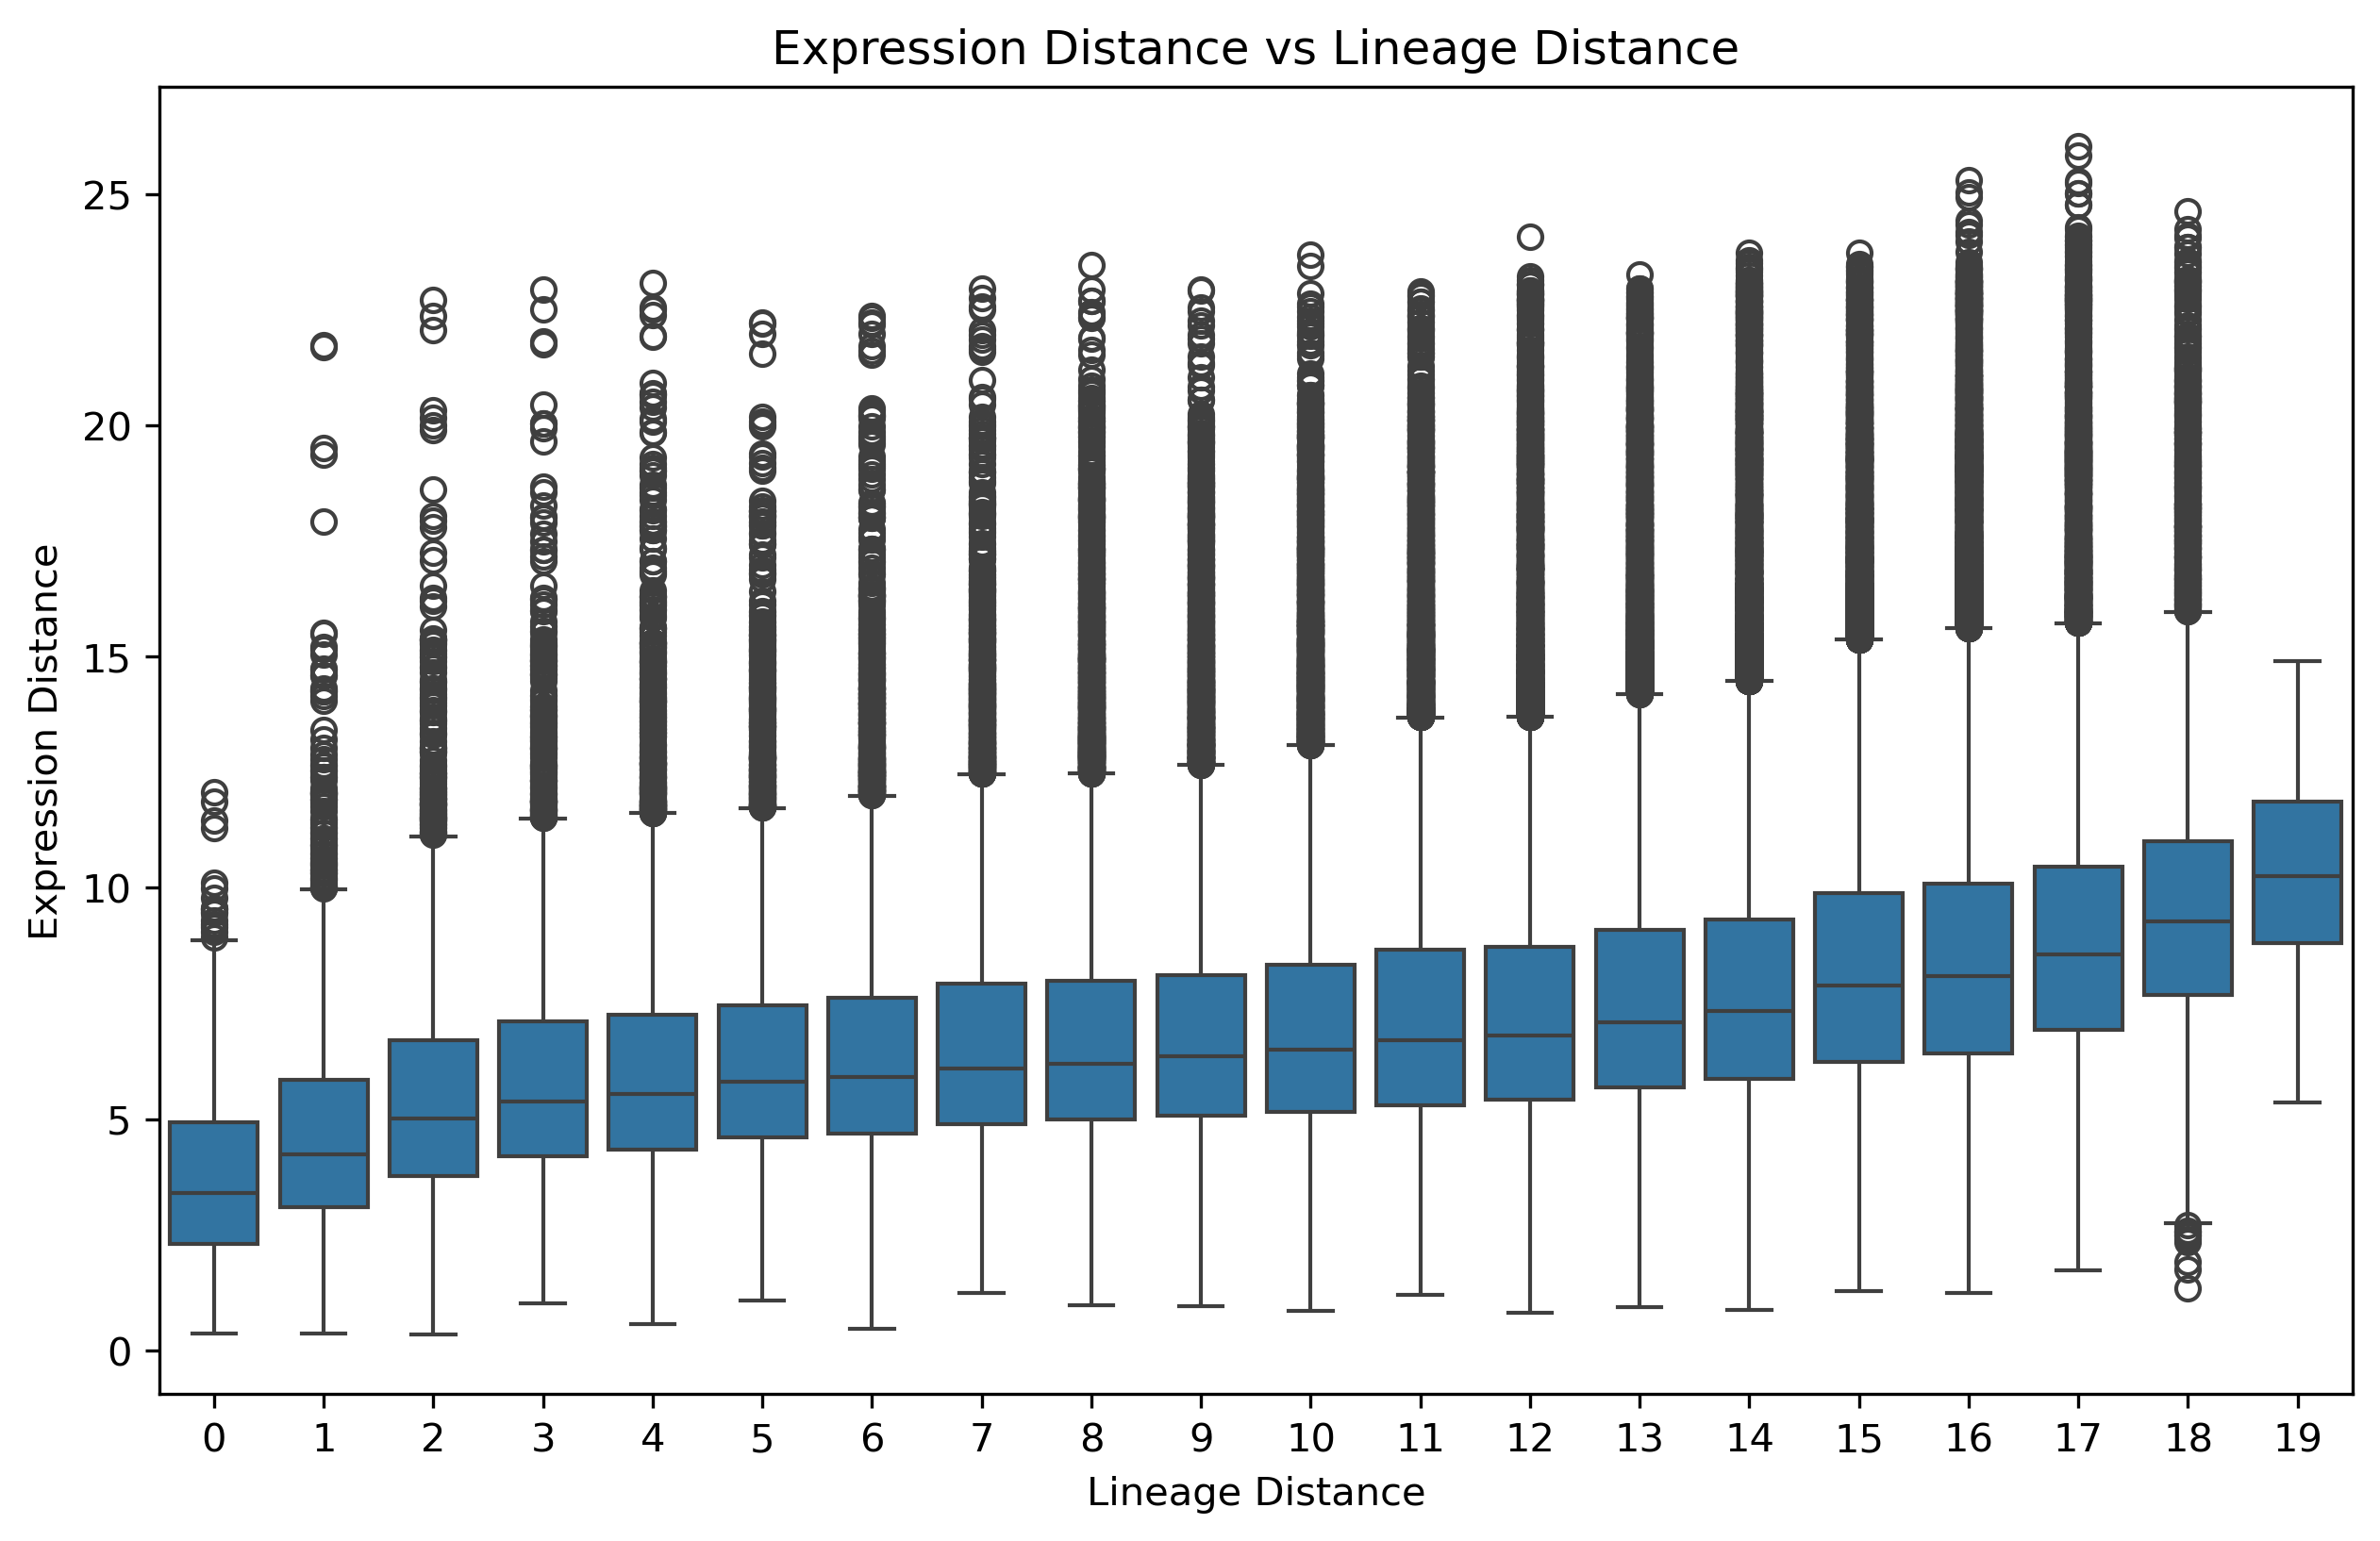

In [26]:
# plot lineage_distances againgst jsd_distances
# since lineage distance is discrete and jsd_distance is continuous we create a boxplot for each lineage distance
lineage_jsd_df = pd.DataFrame({'lineage_distance': lineage_distances, 'exp_distance': exp_distances})
plt.figure(figsize=(10, 6))
sns.boxplot(x='lineage_distance', y='exp_distance', data=lineage_jsd_df)
plt.title('Expression Distance vs Lineage Distance')
plt.xlabel('Lineage Distance')
plt.ylabel('Expression Distance')
plt.show()

In [27]:
same_type_siblings = []
diff_type_siblings = []
for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    if len(child_types) == 1 and len(children) > 1:
        same_type_siblings.append(children)
    elif len(child_types) > 1:
        diff_type_siblings.append(children)


In [28]:
same_type_dist_mean = []
same_type_dist_std = []
diff_type_dist_mean = []
diff_type_dist_std = []
for tf in protein_exp.index:
    tf_values = protein_exp.loc[tf]
    distances = []
    for sib1, sib2 in same_type_siblings:
        distances.append(np.abs(tf_values[sib1] - tf_values[sib2]))
    same_type_dist_mean.append(np.mean(distances))
    same_type_dist_std.append(np.std(distances))
    distances = []
    for sib1, sib2 in diff_type_siblings:
        distances.append(np.abs(tf_values[sib1] - tf_values[sib2]))
    diff_type_dist_mean.append(np.mean(distances))
    diff_type_dist_std.append(np.std(distances))

dist_df = pd.DataFrame({
    "TF": protein_exp.index,
    "Same Type Siblings Mean Distance": same_type_dist_mean,
    "Same Type Siblings Std Distance": same_type_dist_std,
    "Diff Type Siblings Mean Distance": diff_type_dist_mean,
    "Diff Type Siblings Std Distance": diff_type_dist_std,
})
dist_df.index = dist_df["TF"]


In [29]:
xyz_coord_dict = {}
exp_vector_dict = {}
alt_exp_vector_dict = {}
embedded_exp_vector_dict = {}

for node, parent in zip(terminal_nodes, terminal_parents):
    xyz_coord_dict[node] = ts_df.loc[ts_df['name'] == node].values[-1][1:4]*0.1625
    xyz_coord_dict[parent] = ts_df.loc[ts_df['name'] == parent].values[-1][1:4]*0.1625
    exp_vector_dict[node] = protein_exp.loc[:, node].values
    exp_vector_dict[parent] = protein_exp.loc[:, parent].values
    alt_exp_vector_dict[node] = alt_tf_exp.loc[:, node].values
    alt_exp_vector_dict[parent] = alt_tf_exp.loc[:, parent].values
    embedded_exp_vector_dict[node] = lineage_exp.loc[:, node].values
    embedded_exp_vector_dict[parent] = lineage_exp.loc[:, parent].values


In [30]:
siblings_exp_distances_with_same_type = []
siblings_exp_distances_with_diff_type = []
sibling_parent_distances_with_same_type = []
sibling_parent_distances_with_diff_type = []

for parent, children in terminal_parents_dict.items():
    child_types = set()
    for child in children:
        child_type = lineage_type_dict.get(child, None)
        if child_type is not None:
            child_types.add(child_type)
    if len(child_types) == 1 and len(children) > 1:
        siblings_exp_distances_with_same_type.append(np.mean([np.linalg.norm(lineage_exp[child1] - lineage_exp[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_same_type.append(np.mean([np.linalg.norm(lineage_exp[child] - lineage_exp[parent]) for child in children]))
    elif len(child_types) > 1:
        siblings_exp_distances_with_diff_type.append(np.mean([np.linalg.norm(lineage_exp[child1] - lineage_exp[child2]) for i, child1 in enumerate(children) for j, child2 in enumerate(children) if i < j]))
        sibling_parent_distances_with_diff_type.append(np.mean([np.linalg.norm(lineage_exp[child] - lineage_exp[parent]) for child in children]))

    # if len(child_types) == 1 and len(children) > 1:
    #     siblings_exp_distances_with_same_type.append(
    #         np.mean([js_distance_matrix_df.loc[c1, c2]
    #                  for i, c1 in enumerate(children)
    #                  for j, c2 in enumerate(children) if i < j]))
    #     sibling_parent_distances_with_same_type.append(
    #         np.mean([js_distance_matrix_df.loc[c, parent] for c in children]))
    # elif len(child_types) > 1:
    #     siblings_exp_distances_with_diff_type.append(
    #         np.mean([js_distance_matrix_df.loc[c1, c2]
    #                  for i, c1 in enumerate(children)
    #                  for j, c2 in enumerate(children) if i < j]))
    #     sibling_parent_distances_with_diff_type.append(
    #         np.mean([js_distance_matrix_df.loc[c, parent] for c in children]))


In [31]:
print(f"Avg sibling expression distance with same type: {np.mean(siblings_exp_distances_with_same_type):.4f}")
print(f"Avg sibling expression distance with different type: {np.mean(siblings_exp_distances_with_diff_type):.4f}")
print(f"Avg sibling-parent expression distance with same type: {np.mean(sibling_parent_distances_with_same_type):.4f}")
print(f"Avg sibling-parent expression distance with different type: {np.mean(sibling_parent_distances_with_diff_type):.4f}")


Avg sibling expression distance with same type: 3.3276
Avg sibling expression distance with different type: 4.4302
Avg sibling-parent expression distance with same type: 4.5736
Avg sibling-parent expression distance with different type: 5.9880


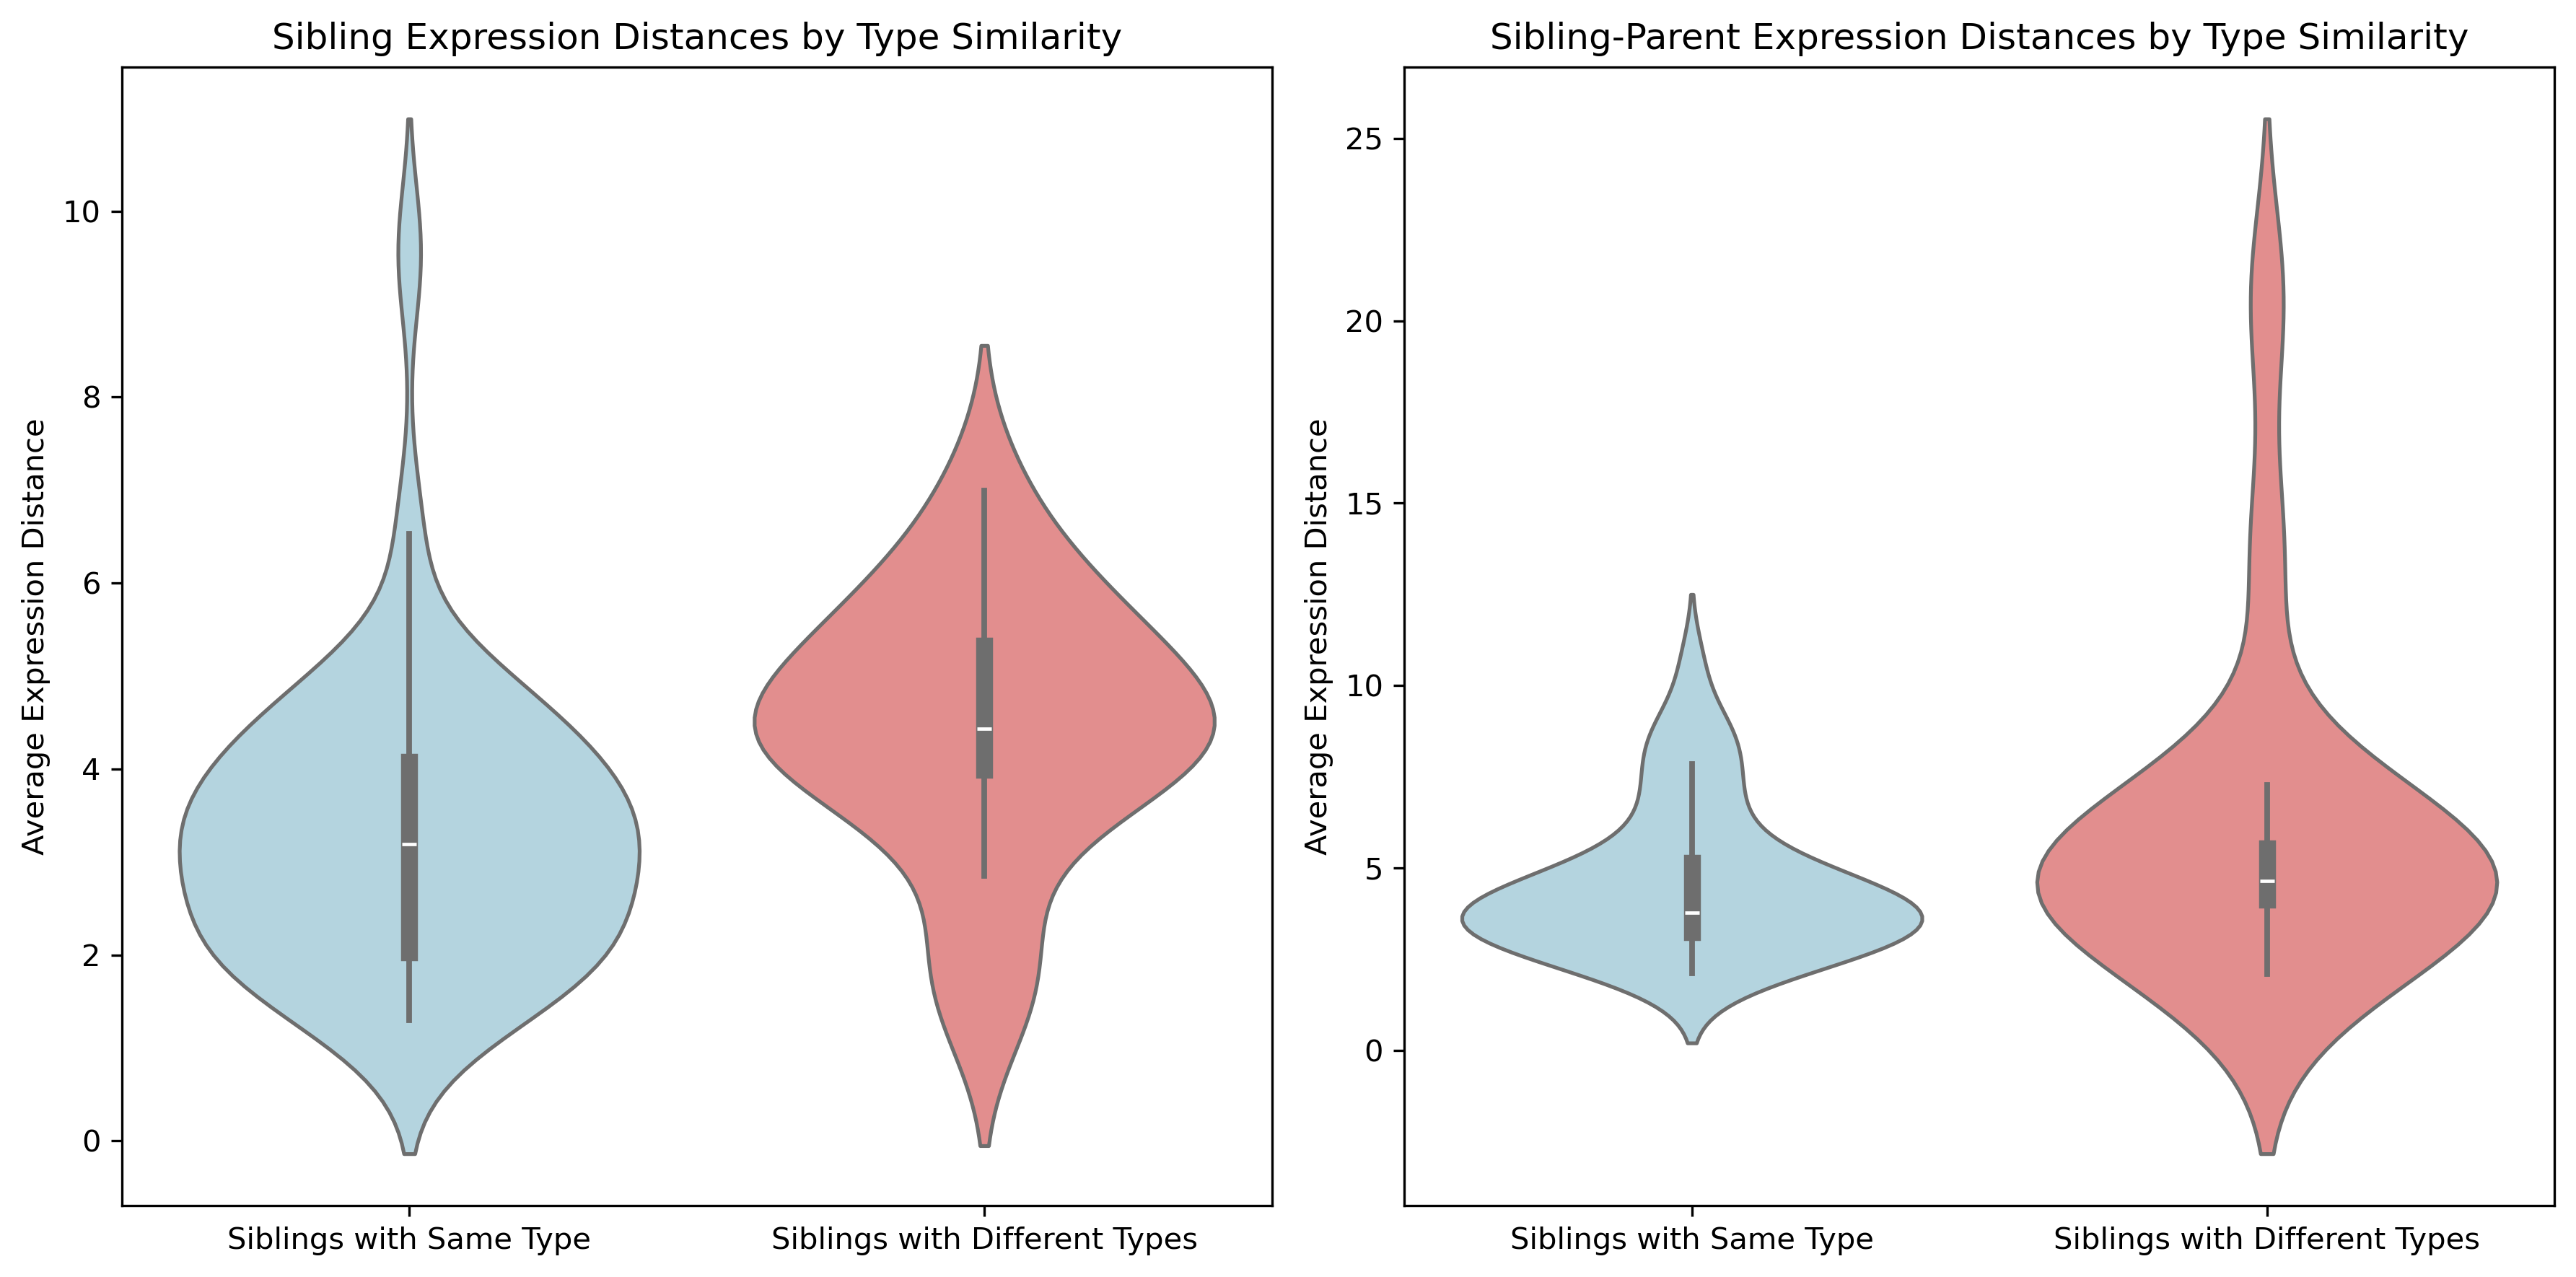

In [32]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.violinplot(data=[siblings_exp_distances_with_same_type, siblings_exp_distances_with_diff_type],
               palette=["lightblue", "lightcoral"])
plt.xticks([0, 1], ['Siblings with Same Type', 'Siblings with Different Types'])
plt.ylabel('Average Expression Distance')
plt.title('Sibling Expression Distances by Type Similarity')

plt.subplot(1, 2, 2)
sns.violinplot(data=[sibling_parent_distances_with_same_type, sibling_parent_distances_with_diff_type],
               palette=["lightblue", "lightcoral"])
plt.xticks([0, 1], ['Siblings with Same Type', 'Siblings with Different Types'])
plt.ylabel('Average Expression Distance')
plt.title('Sibling-Parent Expression Distances by Type Similarity')
plt.tight_layout()
plt.show()


In [33]:
xyz_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
alt_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))
embedded_exp_cost_mat = np.zeros((len(terminal_parents), len(terminal_nodes)))

for i, parent in enumerate(terminal_parents):
    for j, node in enumerate(terminal_nodes):
        xyz_cost_mat[i, j] = np.linalg.norm(xyz_coord_dict[parent] - xyz_coord_dict[node])
        exp_cost_mat[i, j] = np.linalg.norm(exp_vector_dict[parent] - exp_vector_dict[node])
        alt_exp_cost_mat[i, j] = np.linalg.norm(alt_exp_vector_dict[parent] - alt_exp_vector_dict[node])
        embedded_exp_cost_mat[i, j] = np.linalg.norm(embedded_exp_vector_dict[parent] - embedded_exp_vector_dict[node])

lineage_xyz_cost = xyz_cost_mat.diagonal().sum()
lineage_exp_cost = exp_cost_mat.diagonal().sum()
lineage_alt_exp_cost = alt_exp_cost_mat.diagonal().sum()
lineage_embedded_exp_cost = embedded_exp_cost_mat.diagonal().sum()


Pearson correlation


,protein_tf_cost,scrna_cost,embedding_cost
protein_tf_cost,1.000000,-0.073400,0.882835
scrna_cost,-0.073400,1.000000,-0.070326
embedding_cost,0.882835,-0.070326,1.000000


Spearman correlation


,protein_tf_cost,scrna_cost,embedding_cost
protein_tf_cost,1.000000,-0.061931,0.850898
scrna_cost,-0.061931,1.000000,-0.058254
embedding_cost,0.850898,-0.058254,1.000000


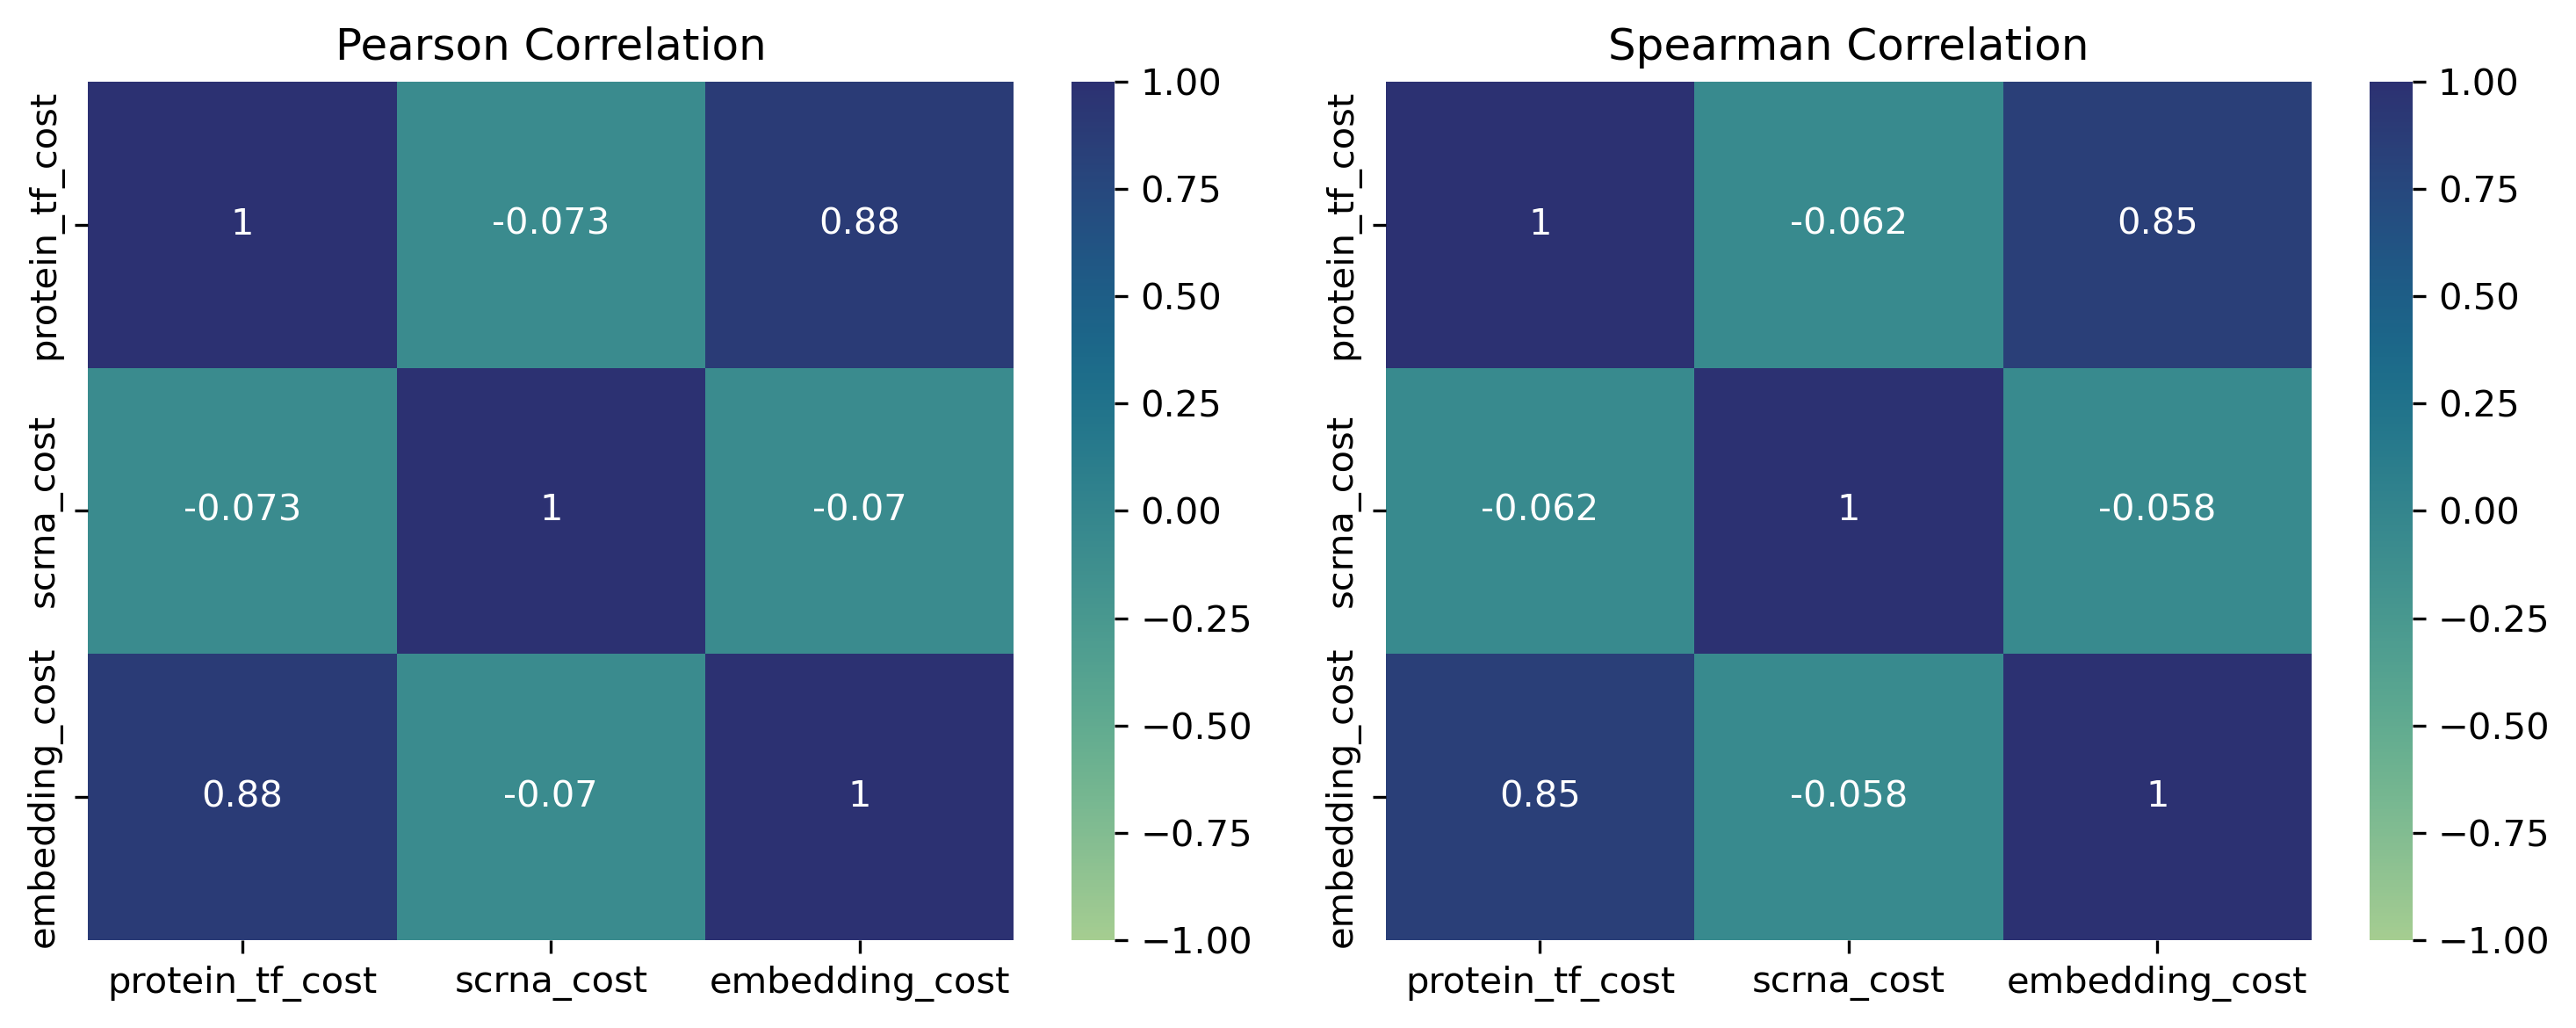

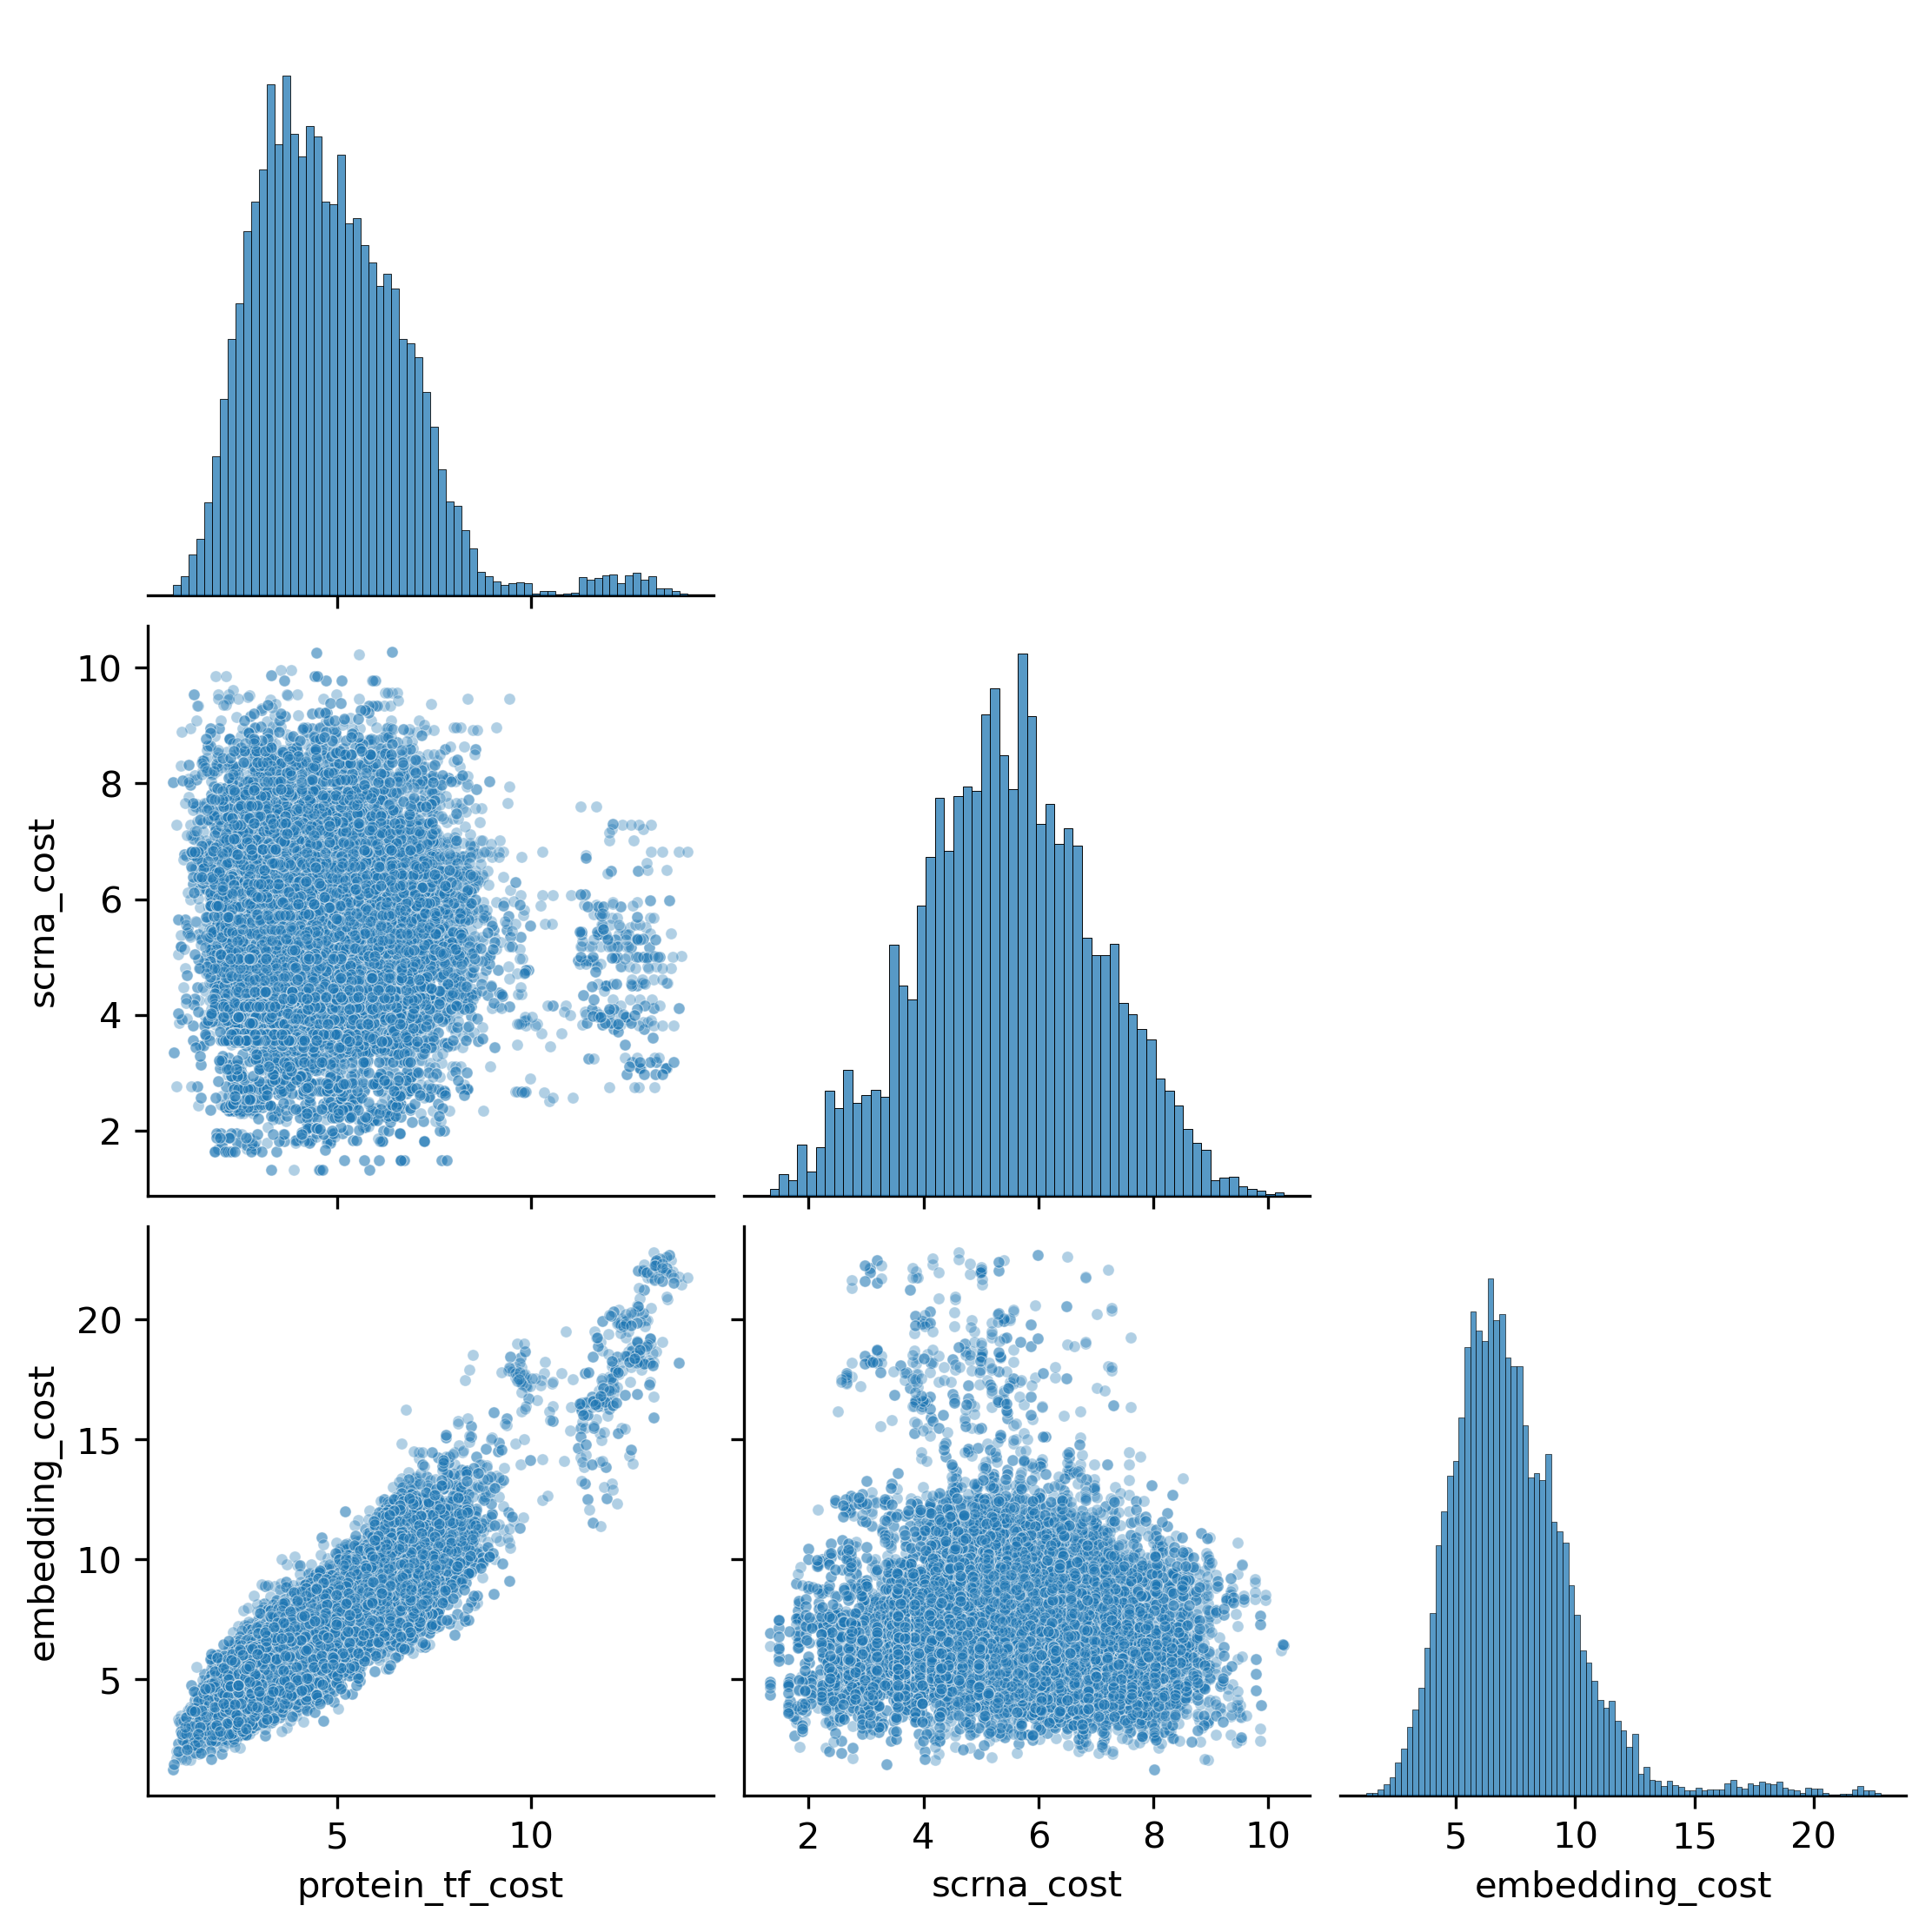

In [34]:
upper_triangle_mask = np.triu(np.ones(exp_cost_mat.shape, dtype=bool), k=1)

cost_comparison_df = pd.DataFrame({
    'protein_tf_cost': exp_cost_mat[upper_triangle_mask],
    'scrna_cost': alt_exp_cost_mat[upper_triangle_mask],
    'embedding_cost': embedded_exp_cost_mat[upper_triangle_mask],
})

pearson_corr = cost_comparison_df.corr(method='pearson')
spearman_corr = cost_comparison_df.corr(method='spearman')

print('Pearson correlation')
display(pearson_corr)
print('Spearman correlation')
display(spearman_corr)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(pearson_corr, annot=True, cmap='crest', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation')
sns.heatmap(spearman_corr, annot=True, cmap='crest', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation')
plt.tight_layout()
plt.show()

sns.pairplot(cost_comparison_df, kind='scatter', corner=True, plot_kws={'s': 10, 'alpha': 0.35})
plt.show()

In [35]:
def pareto_exp_comp(chosen_exp_cost, title):
    pareto_xyz_costs = []
    pareto_exp_costs = []
    pareto_alt_exp_costs = []
    pareto_house_keeping_exp_costs = []
    for i in tqdm(range(1001)):
        alpha = i / 1000.0
        combined_cost_mat = alpha * chosen_exp_cost + (1 - alpha) * xyz_cost_mat
        row_ind, col_ind = linear_sum_assignment(combined_cost_mat)
        pareto_xyz_costs.append(xyz_cost_mat[row_ind, col_ind].sum())
        pareto_exp_costs.append(exp_cost_mat[row_ind, col_ind].sum())
        pareto_alt_exp_costs.append(alt_exp_cost_mat[row_ind, col_ind].sum())
        pareto_house_keeping_exp_costs.append(embedded_exp_cost_mat[row_ind, col_ind].sum())

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 10), sharex=True)
    fig.suptitle(title)
    ax1.plot(pareto_xyz_costs, pareto_exp_costs, marker='o', linestyle='-', color='black', markersize=3)
    ax1.scatter(lineage_xyz_cost, lineage_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax1.set_ylabel('Protein-TF Cost')
    ax1.set_xlabel('Motility Cost')
    ax2.plot(pareto_xyz_costs, pareto_alt_exp_costs, marker='o', linestyle='-', color='black', markersize=3)
    ax2.scatter(lineage_xyz_cost, lineage_alt_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax2.set_ylabel('ScRNA Cost')
    ax2.set_xlabel('Motility Cost')
    ax3.plot(pareto_xyz_costs, pareto_house_keeping_exp_costs, marker='o', linestyle='-', color='black', markersize=3)
    ax3.scatter(lineage_xyz_cost, lineage_embedded_exp_cost, marker='*', color='#FF0000', label='Real Lineage Cost')
    ax3.set_ylabel('Protein-Embedding Cost')
    ax3.set_xlabel('Motility Cost')
    plt.tight_layout()
    plt.show()


100%|██████████| 1001/1001 [00:00<00:00, 1026.22it/s]


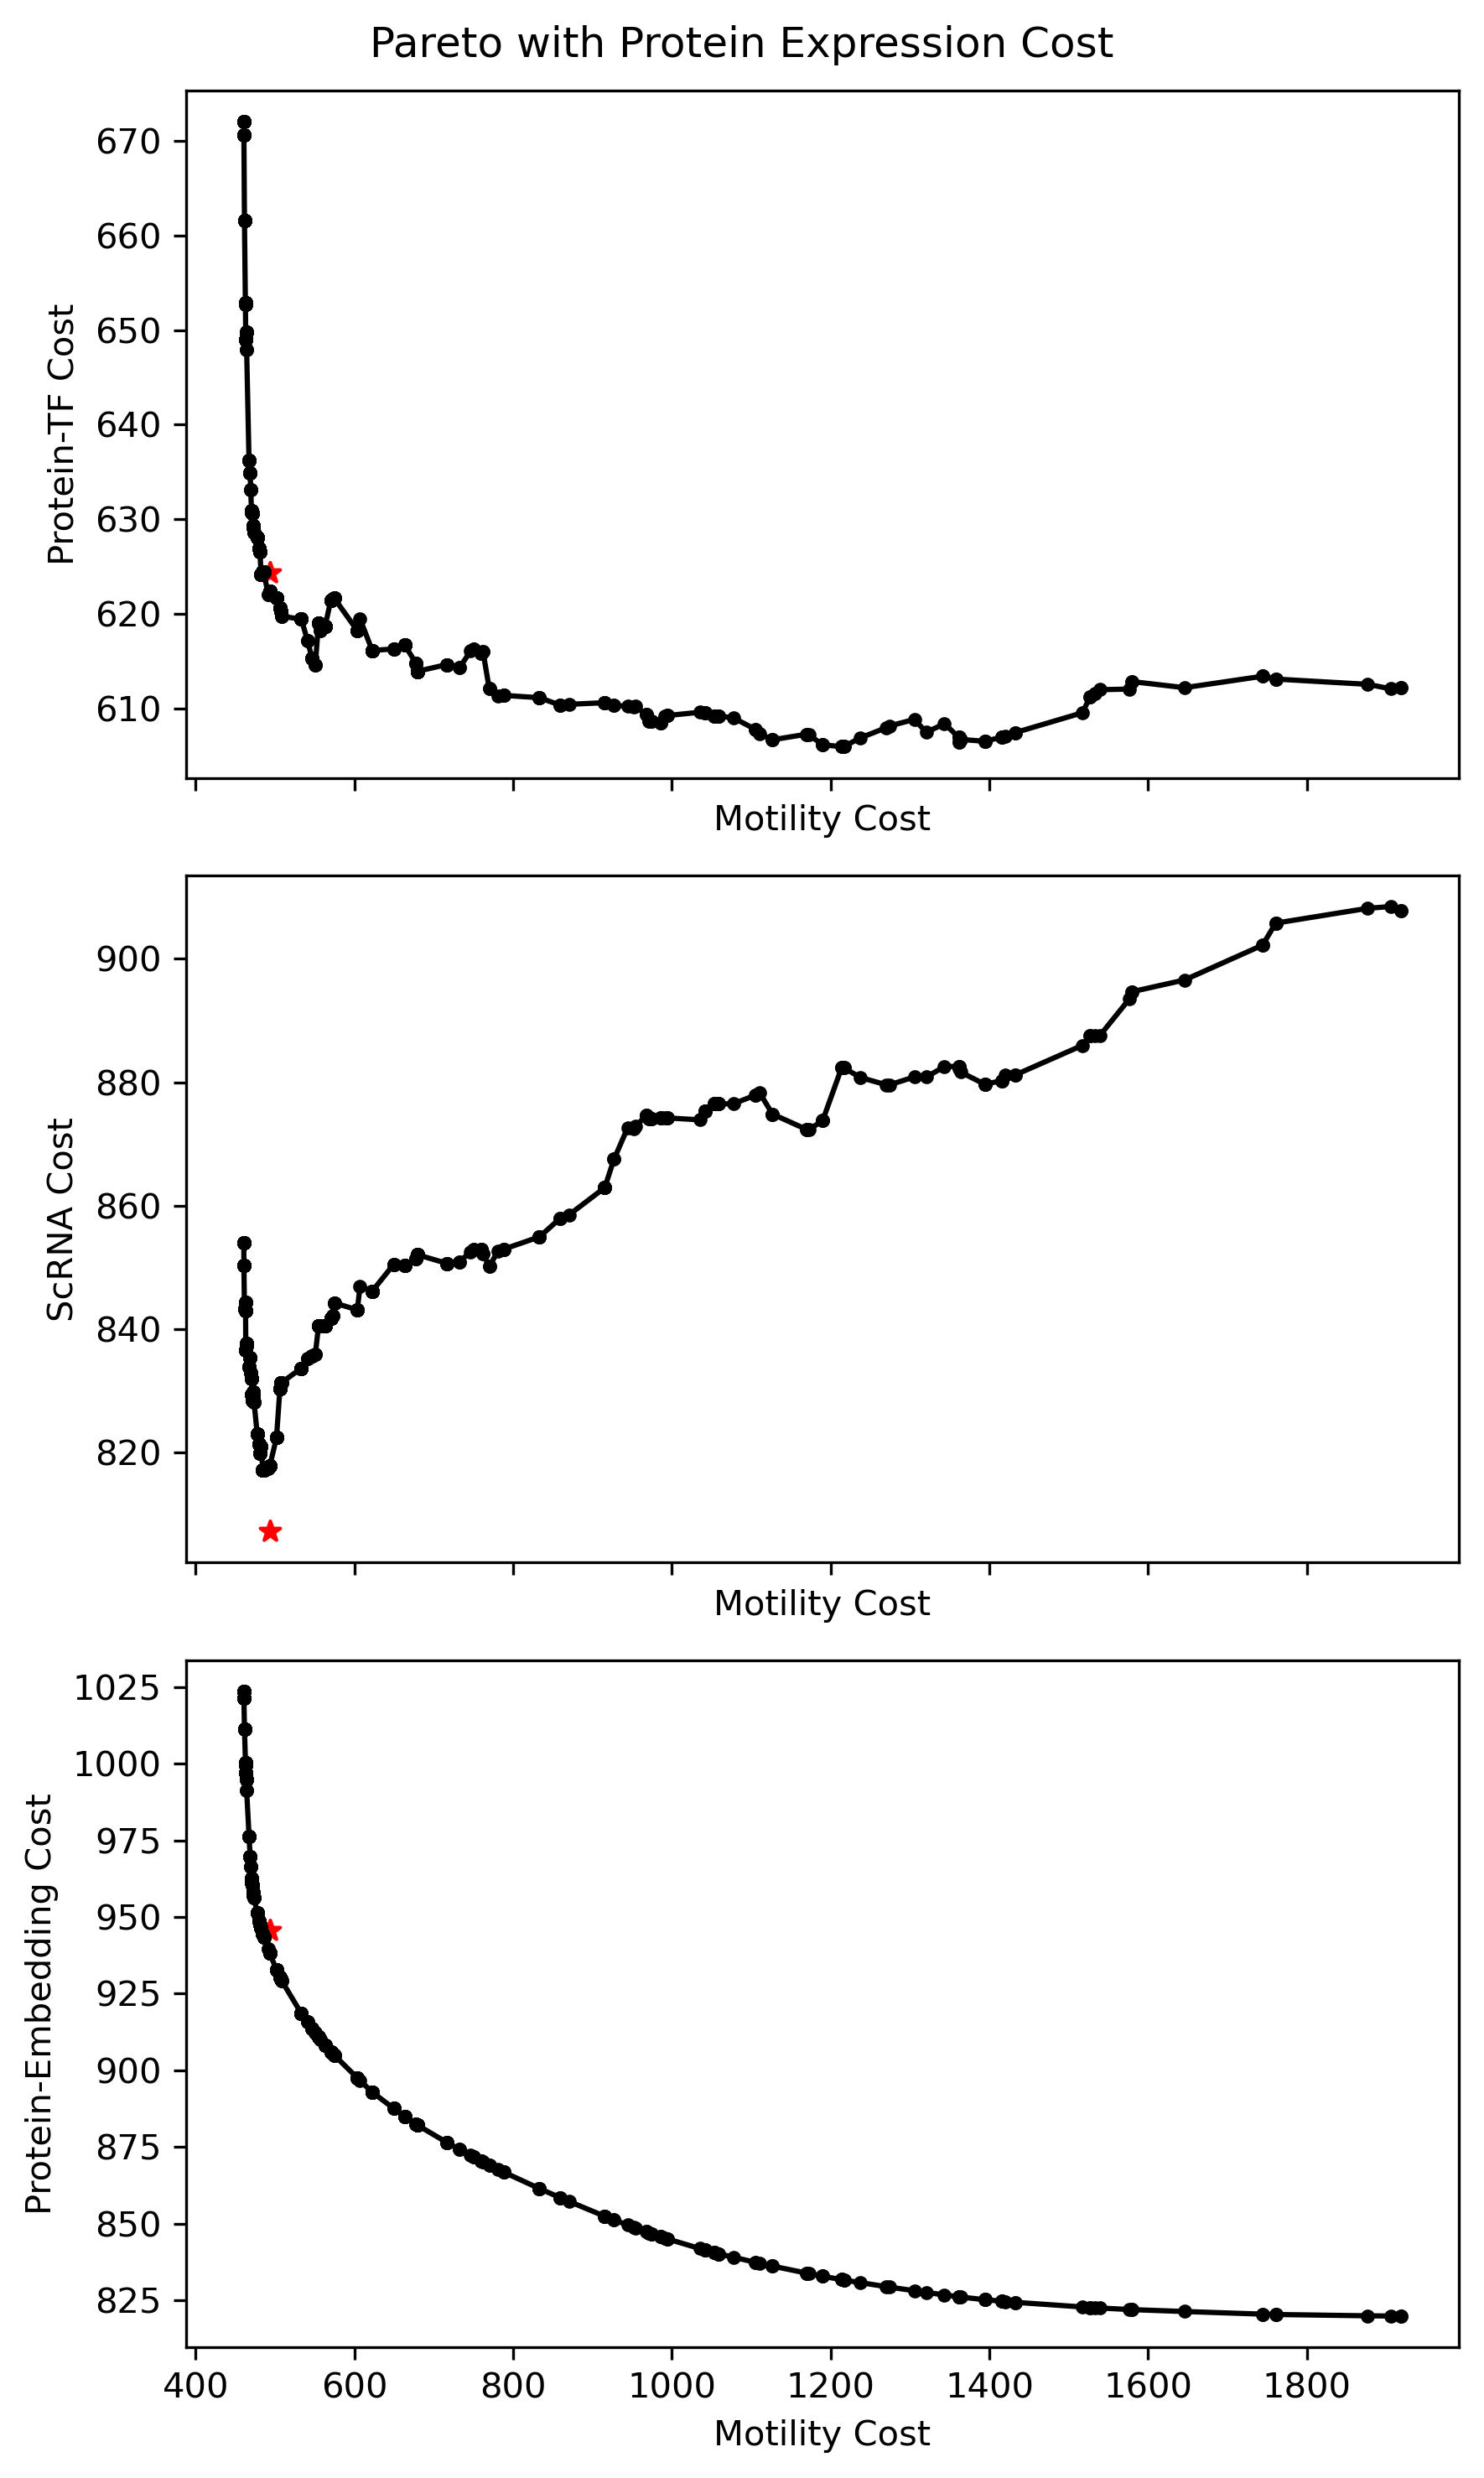

In [36]:
pareto_exp_comp(embedded_exp_cost_mat, "Pareto with Protein Expression Cost")
